In [22]:
import sys
sys.path.insert(0, "../..")

from src.models        import LogDeepONet, build_logdeeponet
from src.data          import ODEIterableDataset, DirichletSampler
from src.physics       import Robertson
from src.training      import Trainer, build_dataloaders

import numpy as np
import matplotlib.pyplot as plt 
import torch
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [23]:
# Initialize Roberston Model
k1 = 4e-2
k2 = 3e7
k3 = 1e4
system = Robertson([k1, k2, k3])

# Initialize Sampler Object 
sampler = DirichletSampler(alpha=[1, 1, 1])

In [24]:
dataset_size = 1001
batch_size   = 1
num_workers  = 2
t_final      = 1e4
t_span       = (0, t_final)

rob_dataset = ODEIterableDataset(size          = dataset_size,
                                 system_class  = system,
                                 sampler       = sampler,
                                 t_span        = t_span,
                                 full_solution = True,
                                 method        = "BDF")

rob_loader  = DataLoader(dataset     = rob_dataset,
                         batch_size  = batch_size,
                         num_workers = num_workers)


In [25]:
# Set Up DeepONet configuration 

DEEPONET_CONFIG = {
    
    "hidden_size" : 64,
    "depth"       : 4,
    "latent_size" : 120,
    "input_size_b": 3,
    "input_size_t": 1,
    "output_size" : 3,
    "activation"  : "tanh",

}

# 1. Initialize DeepONet network 

deeponet = build_logdeeponet(DEEPONET_CONFIG)

# 2. Load the saved weights into the model

state_dict = torch.load("../../weights/best_robertson.pth", map_location=device)
deeponet.load_state_dict(state_dict)
deeponet = deeponet.to(device)

# 3. Set to eval mode
deeponet.eval()
_ = 0

In [26]:
from src.benchmark import trajectory 

t, sol, pred = trajectory(deeponet, rob_loader, device)

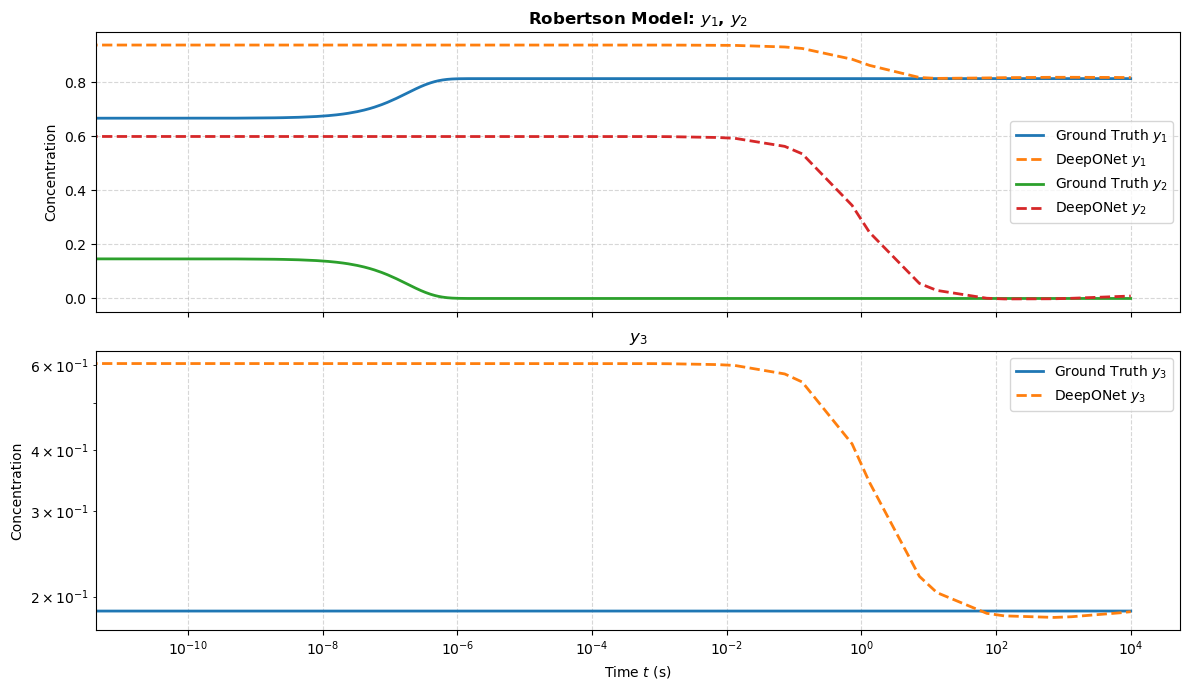

In [29]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# --- Top plot: y1, y2 ---
for i in range(2):
    ax1.plot(t, sol[i], lw=2, label=f"Ground Truth $y_{i+1}$")
    ax1.plot(t, pred[:, i], lw=2, linestyle="--", label=f"DeepONet $y_{i+1}$")

ax1.set_xscale('log')
ax1.set_ylabel("Concentration")
ax1.set_title("Robertson Model: $y_1$, $y_2$", fontweight="bold")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.5)

# --- Bottom plot: y3 ---
i = 2
ax2.plot(t, sol[i], lw=2, label="Ground Truth $y_3$")
ax2.plot(t, pred[:, i], lw=2, linestyle="--", label="DeepONet $y_3$")

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel("Time $t$ (s)")
ax2.set_ylabel("Concentration")
ax2.set_title("$y_3$")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()